In [188]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# test signal
一个30hz正弦波，处于blackman-harris半主瓣里  
sr = 48000
fc = 30  
fft_size = 2048 
zero_pad = 2  
hop_size = 512  
total_len = hop_size * 512  

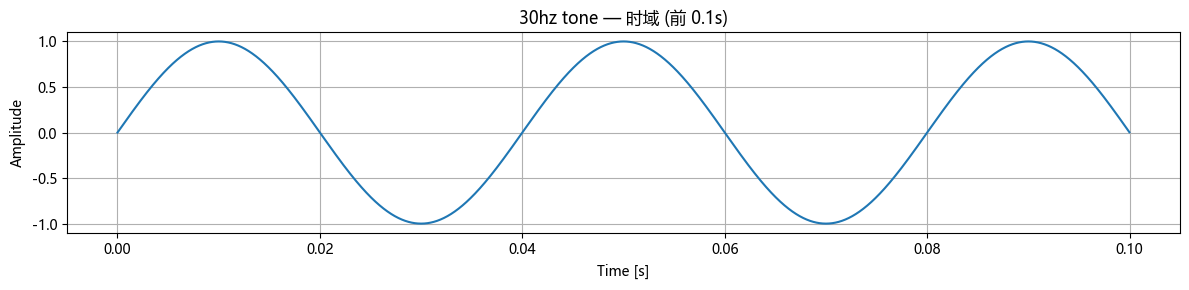

In [189]:
sr = 48000
fft_size = 2048
zero_pad = 2
hop_size = 512
total_len = fft_size * 32

t = np.arange(total_len) / sr
T = total_len / sr  # 总时长

# 原 FM 调制正弦波（载波 2k，调制 1Hz，频偏 1k）
fc = 25.0
y = np.sin(2 * np.pi * fc * t)

plt.figure(figsize=(12, 3))
plt.plot(t[:4800], y[:4800])
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("30hz tone — 时域 (前 0.1s)")
plt.grid(True)
plt.tight_layout()
plt.show()

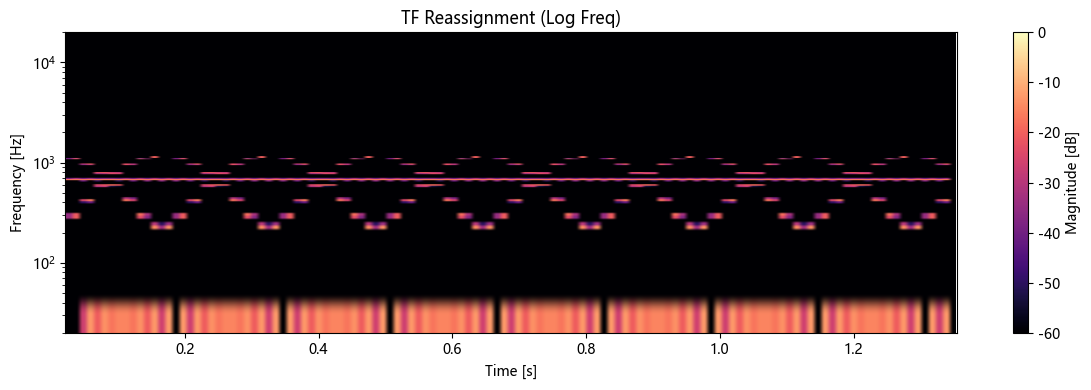

In [190]:
# ------------------------------------------------------------
# 纯对数版本 — 频率重分配（带零填充）
# ------------------------------------------------------------
# 在 log10 空间构建等距网格:
#   log_f_axis = linspace(log10(f_min), log10(f_max), N)
#   f_axis     = 10^log_f_axis      ← 等比数列
#
# 频率重分配时:
#   inst_freq 转为 log10 → 在线性 log 网格上做线性分布
# 时间重分配不变
# ============================================================


def reassigned_spectrogram_log(
    y,
    sr,
    n_fft=2048,
    hop=512,
    zero_pad=1,
    window=None,
    vmin=-60,
    vmax=0,
    f_lim=(1, 100),
    title=None,
):
    fft_len = n_fft * zero_pad
    n_freq_out = fft_len // 2 + 1
    if window is None:
        w = signal.windows.blackman(n_fft)
    else:
        w = window

    n_frames = (len(y) - n_fft) // hop + 1
    frame_dur = n_fft / sr

    f_min, f_max = f_lim
    log_f_min = np.log10(f_min)
    log_f_max = np.log10(f_max)

    # log 空间等距网格
    log_freq_axis = np.linspace(log_f_min, log_f_max, n_freq_out)
    freq_axis = 10**log_freq_axis

    grid = np.zeros((n_frames, n_freq_out))
    time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr
    dt = hop / sr

    for m in range(n_frames):
        seg = y[m * hop : m * hop + n_fft]

        X_h = np.fft.rfft(seg * w, n=fft_len)

        seg_shift = np.roll(seg, 1)
        seg_shift[0] = 0.0
        X_t = np.fft.rfft(seg_shift * w, n=fft_len)
        cross_t = X_h * np.conj(X_t)
        inst_freq_hz = np.mod(np.angle(cross_t) / (2 * np.pi), 1.0) * sr

        X_pf = np.roll(X_h, 1)
        X_pf[0] = 0.0
        cross_f = X_h * np.conj(X_pf)
        arg_f = np.mod(np.angle(cross_f) / (2 * np.pi), 1.0)
        group_delay = 0.5 - arg_f

        mag_lin = np.abs(X_h) / n_fft
        t_center = time_axis[m]

        for k in range(n_freq_out):
            f_reassigned = np.clip(inst_freq_hz[k], f_min, f_max)
            # 转 log10 → 在 log 空间做线性分布
            log_f = np.log10(f_reassigned)
            f_pos = (log_f - log_f_min) / (log_f_max - log_f_min) * (n_freq_out - 1)
            f_idx = int(np.floor(f_pos))
            f_frac = f_pos - f_idx
            if f_idx < 0 or f_idx >= n_freq_out - 1:
                continue

            t_reassigned = t_center + group_delay[k] * frame_dur
            t_pos = (t_reassigned - time_axis[0]) / dt
            t_idx = int(np.floor(t_pos))
            t_frac = t_pos - t_idx
            if t_idx < 0 or t_idx >= n_frames - 1:
                continue

            wgt = mag_lin[k]
            grid[t_idx, f_idx] += wgt * (1 - t_frac) * (1 - f_frac)
            grid[t_idx, f_idx + 1] += wgt * (1 - t_frac) * f_frac
            grid[t_idx + 1, f_idx] += wgt * t_frac * (1 - f_frac)
            grid[t_idx + 1, f_idx + 1] += wgt * t_frac * f_frac

    # ----- 绘制 -----
    grid_db = 20 * np.log10(grid.T + 1e-12)
    extent = [time_axis[0], time_axis[-1] + hop / sr, freq_axis[0], freq_axis[-1]]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(
        grid_db,
        aspect="auto",
        origin="lower",
        cmap="magma",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_yscale("log")
    ax.set_ylim(f_min, f_max)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(title or "TF Reassignment (Log Freq)")
    fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap="magma"),
        ax=ax,
        label="Magnitude [dB]",
    )
    fig.tight_layout()
    plt.show()

reassigned_spectrogram_log(y, sr, f_lim=(20, 20000), hop=512, zero_pad=1)

# 导数窗
在进入DFT前，我想再对比一下使用导数窗的版本

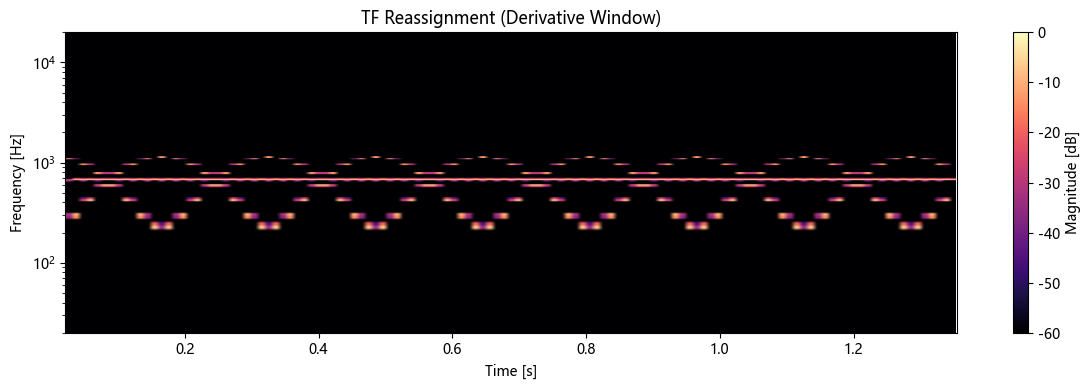

In [191]:
# ------------------------------------------------------------
# 导数窗 / 时间矩重分配版本
# ------------------------------------------------------------
# 参考 C++ TfDerivativeReassignmentFrame
#
# X_h  = FFT(x · w)
# X_dh = FFT(x · dw)              — 导数窗 → 频率重分配
# X_th = FFT(x · (n-N/2)·w[n])   — 时间加权窗 → 时间重分配
#
# 重分配公式 (Auger & Flandrin):
#   f̂_k = f_k + Im(conj(X_h)·X_dh) / (2π · |X_h|²)   [Hz 修正]
#   t̂   = t   + Re(conj(X_h)·X_th) / (|X_h|² · N)    [帧长归一化偏移]
# ============================================================


def _blackman_window(n_fft):
    """周期式 (periodic) Blackman 窗及其解析导数"""
    a0, a1, a2 = 0.42, 0.5, 0.08
    n = np.arange(n_fft)
    t = n / n_fft  # 周期式归一化
    twopi = 2 * np.pi
    w = a0 - a1 * np.cos(twopi * t) + a2 * np.cos(2 * twopi * t)
    # 解析导数 (d(w)/dt, 不包含 1/N 因子, 即 N·dw/dn)
    dw = a1 * twopi * np.sin(twopi * t) \
       - a2 * (2 * twopi) * np.sin(2 * twopi * t)
    return w, dw


def reassigned_spectrogram_deriv(
    y,
    sr,
    n_fft=2048,
    hop=512,
    zero_pad=1,
    window=None,
    vmin=-60,
    vmax=0,
    f_lim=(1, 100),
    title=None,
):
    fft_len = n_fft * zero_pad
    n_freq_out = fft_len // 2 + 1

    if window is None:
        w, dw = _blackman_window(n_fft)
        # 增益归一化 (与 C++ Helper::NormalizeGain 等价)
        w_gain = 1.0 / np.mean(w)
        w *= w_gain
        dw *= w_gain
    else:
        w = window
        dw = np.gradient(w)
        w_gain = 1.0 / np.mean(w)
        dw *= w_gain

    # 时间加权窗: (n - N/2) · w[n]  (与 C++ TWindow 一致)
    n_arr = np.arange(n_fft)
    offset = n_fft / 2.0
    tw = w * (n_arr - offset)

    n_frames = (len(y) - n_fft) // hop + 1
    frame_dur = n_fft / sr

    f_min, f_max = f_lim
    log_f_min = np.log10(f_min)
    log_f_max = np.log10(f_max)

    # 输出 log 网格
    log_freq_axis = np.linspace(log_f_min, log_f_max, n_freq_out)
    freq_axis = 10**log_freq_axis

    grid = np.zeros((n_frames, n_freq_out))
    time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr
    dt = hop / sr

    # bin 频率 (Hz): f_k = k * sr / fft_len
    bin_hz = sr / fft_len
    bin_freqs = np.arange(n_freq_out) * bin_hz

    for m in range(n_frames):
        seg = y[m * hop : m * hop + n_fft]

        # ── 3 个 FFT ──
        X_h = np.fft.rfft(seg * w, n=fft_len)
        X_dh = np.fft.rfft(seg * dw, n=fft_len)
        X_th = np.fft.rfft(seg * tw, n=fft_len)

        mag_sq = np.maximum(np.abs(X_h) ** 2, 1e-20)
        mag_lin = np.abs(X_h) / n_fft
        t_center = time_axis[m]

        # ── 导数窗频率重分配 ──
        # C++: freq_c = -Im(conj(X_h)·X_dh/(2π)) / |X_h|² · zeroPad
        # inst_freq = (k + freq_c) · sr / fftLen
        freq_corr = -np.imag(np.conj(X_h) * X_dh) * zero_pad / (2 * np.pi * mag_sq)
        inst_freq_hz = (np.arange(n_freq_out) + freq_corr) * bin_hz

        # ── 时间矩重分配 ──
        # C++: time_offset = Re(conj(X_h)·X_th) / |X_h|²
        # group_delay = time_offset / n_fft  --> in [-0.5, 0.5]
        time_offset = np.real(np.conj(X_h) * X_th) / mag_sq
        group_delay = time_offset / n_fft

        for k in range(n_freq_out):
            f_reassigned = inst_freq_hz[k]
            if f_reassigned < f_min or f_reassigned > f_max:
                continue

            log_f = np.log10(f_reassigned)
            f_pos = (log_f - log_f_min) / (log_f_max - log_f_min) * (n_freq_out - 1)
            f_idx = int(np.floor(f_pos))
            f_frac = f_pos - f_idx
            if f_idx < 0 or f_idx >= n_freq_out - 1:
                continue

            # t̂ = t_center + group_delay · frame_dur
            t_reassigned = t_center + group_delay[k] * frame_dur
            t_pos = (t_reassigned - time_axis[0]) / dt
            t_idx = int(np.floor(t_pos))
            t_frac = t_pos - t_idx
            if t_idx < 0 or t_idx >= n_frames - 1:
                continue

            wgt = mag_lin[k]
            grid[t_idx, f_idx] += wgt * (1 - t_frac) * (1 - f_frac)
            grid[t_idx, f_idx + 1] += wgt * (1 - t_frac) * f_frac
            grid[t_idx + 1, f_idx] += wgt * t_frac * (1 - f_frac)
            grid[t_idx + 1, f_idx + 1] += wgt * t_frac * f_frac

    # ----- 绘制 -----
    grid_db = 20 * np.log10(grid.T + 1e-12)
    extent = [time_axis[0], time_axis[-1] + hop / sr, freq_axis[0], freq_axis[-1]]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(
        grid_db,
        aspect="auto",
        origin="lower",
        cmap="magma",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_yscale("log")
    ax.set_ylim(f_min, f_max)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(title or "TF Reassignment (Derivative Window)")
    fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap="magma"),
        ax=ax,
        label="Magnitude [dB]",
    )
    fig.tight_layout()
    plt.show()


reassigned_spectrogram_deriv(y, sr, f_lim=(20, 20000), hop=512, zero_pad=1)

# NO FFT
让我们使用最原始的DFT来测试  
我需要纠正频率bin并不是k/N*2pi  
而是(k+0.5)/N*pi  

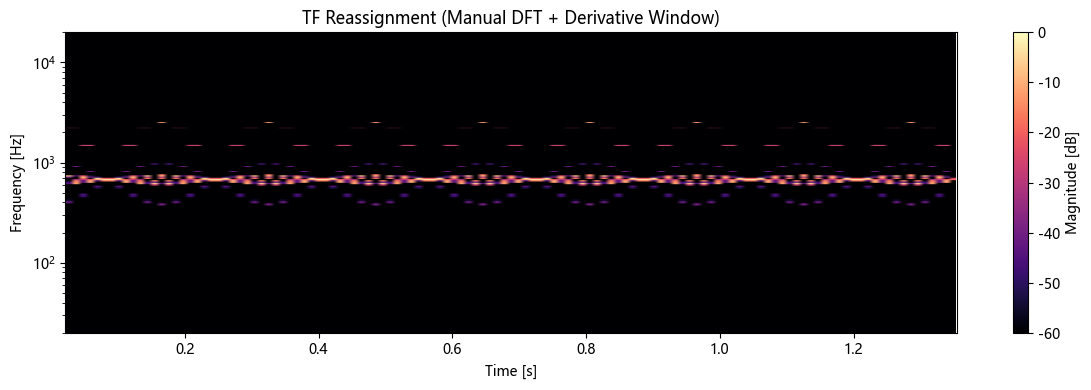

In [192]:
# ------------------------------------------------------------
# 手动 DFT 版本 — 半 bin 偏移频率重分配
# ------------------------------------------------------------
# 频率轴: f_k = (2k+1) * sr / (2 * n_fft), k = 0 .. n_fft//2 - 1
# 归一化角频率: ω_k = (2k+1) * π / n_fft
# 对应 (k+0.5)/N*π, 其中 N = n_fft/2 (正频率 bin 数)
# ============================================================


def reassigned_spectrogram_dft(
    y,
    sr,
    n_fft=2048,
    hop=512,
    window=None,
    vmin=-60,
    vmax=0,
    f_lim=(1, 100),
    title=None,
):
    n_freq_out = n_fft // 2

    # 导数窗 + 时间加权窗
    if window is None:
        w, dw = _blackman_window(n_fft)
        w_gain = 1.0 / np.mean(w)
        w *= w_gain
        dw *= w_gain
    else:
        w = window
        dw = np.gradient(w)
        w_gain = 1.0 / np.mean(w)
        dw *= w_gain

    n_arr = np.arange(n_fft)
    offset = n_fft / 2.0
    tw = w * (n_arr - offset)

    n_frames = (len(y) - n_fft) // hop + 1
    frame_dur = n_fft / sr

    f_min, f_max = f_lim
    log_f_min = np.log10(f_min)
    log_f_max = np.log10(f_max)

    # 输出 log 网格
    log_freq_axis = np.linspace(log_f_min, log_f_max, n_freq_out)
    freq_axis = 10**log_freq_axis

    grid = np.zeros((n_frames, n_freq_out))
    time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr
    dt = hop / sr

    # 半 bin 偏移频率 (Hz) — 手动 DFT 的分析频率
    bin_freqs = (2 * np.arange(n_freq_out) + 1) * sr / (2 * n_fft)

    # 预计算 twiddle 因子: exp(-j * π * (2k+1) * n / n_fft)
    n_arange = np.arange(n_fft)
    twiddles = np.zeros((n_freq_out, n_fft), dtype=complex)
    for k in range(n_freq_out):
        twiddles[k] = np.exp(-1j * np.pi * (2 * k + 1) * n_arange / n_fft)

    for m in range(n_frames):
        seg = y[m * hop : m * hop + n_fft]

        # 手动 DFT: X_h, X_dh, X_th
        X_h = twiddles @ (seg * w)
        X_dh = twiddles @ (seg * dw)
        X_th = twiddles @ (seg * tw)

        mag_sq = np.maximum(np.abs(X_h) ** 2, 1e-20)
        mag_lin = np.abs(X_h) / n_fft
        t_center = time_axis[m]

        # ── 导数窗频率重分配 (半 bin 偏移) ──
        # freq_c = -Im(conj(X_h)·X_dh) / (2π · |X_h|²)   (bin 偏移, 无 zeroPad)
        freq_corr = -np.imag(np.conj(X_h) * X_dh) / (2 * np.pi * mag_sq)
        inst_freq_hz = bin_freqs + freq_corr * sr / n_fft

        # ── 时间矩重分配 ──
        time_offset = np.real(np.conj(X_h) * X_th) / mag_sq
        group_delay = time_offset / n_fft

        for k in range(n_freq_out):
            f_reassigned = inst_freq_hz[k]
            if f_reassigned < f_min or f_reassigned > f_max:
                continue

            log_f = np.log10(f_reassigned)
            f_pos = (log_f - log_f_min) / (log_f_max - log_f_min) * (n_freq_out - 1)
            f_idx = int(np.floor(f_pos))
            f_frac = f_pos - f_idx
            if f_idx < 0 or f_idx >= n_freq_out - 1:
                continue

            t_reassigned = t_center + group_delay[k] * frame_dur
            t_pos = (t_reassigned - time_axis[0]) / dt
            t_idx = int(np.floor(t_pos))
            t_frac = t_pos - t_idx
            if t_idx < 0 or t_idx >= n_frames - 1:
                continue

            wgt = mag_lin[k]
            grid[t_idx, f_idx] += wgt * (1 - t_frac) * (1 - f_frac)
            grid[t_idx, f_idx + 1] += wgt * (1 - t_frac) * f_frac
            grid[t_idx + 1, f_idx] += wgt * t_frac * (1 - f_frac)
            grid[t_idx + 1, f_idx + 1] += wgt * t_frac * f_frac

    # ----- 绘制 -----
    grid_db = 20 * np.log10(grid.T + 1e-12)
    extent = [time_axis[0], time_axis[-1] + hop / sr, freq_axis[0], freq_axis[-1]]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(
        grid_db,
        aspect="auto",
        origin="lower",
        cmap="magma",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_yscale("log")
    ax.set_ylim(f_min, f_max)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(title or "TF Reassignment (Manual DFT + Derivative Window)")
    fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap="magma"),
        ax=ax,
        label="Magnitude [dB]",
    )
    fig.tight_layout()
    plt.show()


reassigned_spectrogram_dft(y, sr, f_lim=(20, 20000), hop=512)

# 寻找另外的求瞬时频率的方法
phase vocoder里有一个求瞬时频率的，摆他  
频率重分配使用 phase vocoder 求瞬时频率方法  
时间重分配使用时间窗方法  

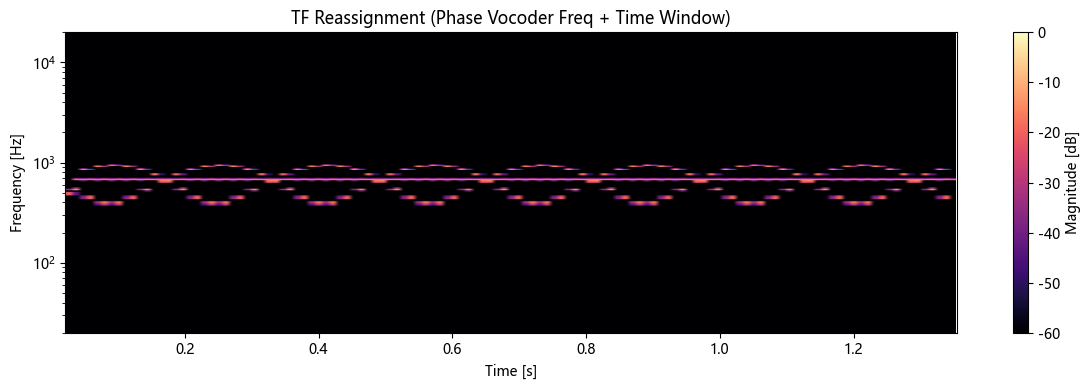

In [193]:
# ------------------------------------------------------------
# Phase Vocoder 瞬时频率 + 时间窗重分配
# ------------------------------------------------------------
# 频率: 相邻帧相位差 → inst_freq (Phase Vocoder 方式)
#   Δφ = angle(X_{m+1}) - angle(X_m)
#   Δφ_wrapped = (Δφ + π) mod 2π - π
#   f_inst = Δφ_wrapped · sr / (2π · hop)
#
# 时间: 时间加权窗法 (与导数窗版本相同)
#   group_delay = Re(conj(X_h)·X_th) / (|X_h|² · N)
# ============================================================


def reassigned_spectrogram_pv(
    y,
    sr,
    n_fft=2048,
    hop=512,
    zero_pad=1,
    window=None,
    vmin=-60,
    vmax=0,
    f_lim=(1, 100),
    title=None,
):
    fft_len = n_fft * zero_pad
    n_freq_out = fft_len // 2 + 1

    if window is None:
        w = signal.windows.blackman(n_fft)
    else:
        w = window

    # 时间加权窗 (仅时间重分配需要)
    n_arr = np.arange(n_fft)
    offset = n_fft / 2.0
    tw = w * (n_arr - offset)

    n_frames = (len(y) - n_fft) // hop + 1
    frame_dur = n_fft / sr

    f_min, f_max = f_lim
    log_f_min = np.log10(f_min)
    log_f_max = np.log10(f_max)

    log_freq_axis = np.linspace(log_f_min, log_f_max, n_freq_out)
    freq_axis = 10**log_freq_axis

    grid = np.zeros((n_frames, n_freq_out))
    time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr
    dt = hop / sr

    # Phase Vocoder 常量
    phase_scale = sr / (2 * np.pi * hop)  # Δφ_wrapped → Hz

    X_h_prev = None
    for m in range(n_frames):
        seg = y[m * hop : m * hop + n_fft]

        X_h = np.fft.rfft(seg * w, n=fft_len)
        X_th = np.fft.rfft(seg * tw, n=fft_len)

        mag_sq = np.maximum(np.abs(X_h) ** 2, 1e-20)
        mag_lin = np.abs(X_h) / n_fft
        t_center = time_axis[m]

        # ── Phase Vocoder 频率重分配 ──
        if m == 0:
            # 首帧无前一帧，退化为 bin 中心频率
            inst_freq_hz = np.arange(n_freq_out) * sr / fft_len
        else:
            Δφ = np.angle(X_h) - np.angle(X_h_prev)
            Δφ_wrapped = (Δφ + np.pi) % (2 * np.pi) - np.pi
            inst_freq_hz = Δφ_wrapped * phase_scale

        # ── 时间窗重分配 ──
        time_offset = np.real(np.conj(X_h) * X_th) / mag_sq
        group_delay = time_offset / n_fft

        for k in range(n_freq_out):
            f_reassigned = inst_freq_hz[k]
            if f_reassigned < f_min or f_reassigned > f_max:
                continue

            log_f = np.log10(f_reassigned)
            f_pos = (log_f - log_f_min) / (log_f_max - log_f_min) * (n_freq_out - 1)
            f_idx = int(np.floor(f_pos))
            f_frac = f_pos - f_idx
            if f_idx < 0 or f_idx >= n_freq_out - 1:
                continue

            t_reassigned = t_center + group_delay[k] * frame_dur
            t_pos = (t_reassigned - time_axis[0]) / dt
            t_idx = int(np.floor(t_pos))
            t_frac = t_pos - t_idx
            if t_idx < 0 or t_idx >= n_frames - 1:
                continue

            wgt = mag_lin[k]
            grid[t_idx, f_idx] += wgt * (1 - t_frac) * (1 - f_frac)
            grid[t_idx, f_idx + 1] += wgt * (1 - t_frac) * f_frac
            grid[t_idx + 1, f_idx] += wgt * t_frac * (1 - f_frac)
            grid[t_idx + 1, f_idx + 1] += wgt * t_frac * f_frac

        X_h_prev = X_h

    # ----- 绘制 -----
    grid_db = 20 * np.log10(grid.T + 1e-12)
    extent = [time_axis[0], time_axis[-1] + hop / sr, freq_axis[0], freq_axis[-1]]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(
        grid_db,
        aspect="auto",
        origin="lower",
        cmap="magma",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_yscale("log")
    ax.set_ylim(f_min, f_max)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(title or "TF Reassignment (Phase Vocoder Freq + Time Window)")
    fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap="magma"),
        ax=ax,
        label="Magnitude [dB]",
    )
    fig.tight_layout()
    plt.show()


reassigned_spectrogram_pv(y, sr, f_lim=(20, 20000), hop=512, zero_pad=1)

# (k+0.5) DFT + phase vocoder + T-window

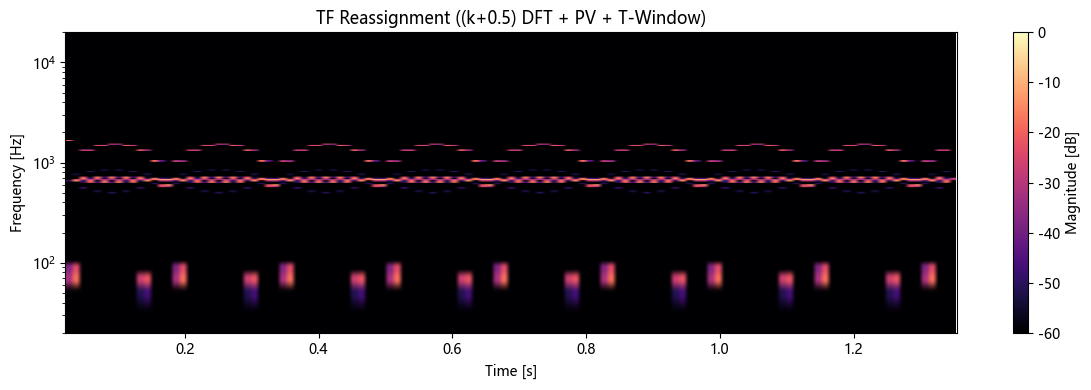

In [194]:
# ------------------------------------------------------------
# (k+0.5) DFT + Phase Vocoder + T-Window
# ------------------------------------------------------------
# 频率轴: f_k = (2k+1) * sr / (2 * n_fft), k = 0 .. n_fft//2 - 1
# 频率重分配: Phase Vocoder (相邻帧相位差)
#    Δφ_wrapped = (Δφ + π) mod 2π - π
#    f_inst = Δφ_wrapped · sr / (2π · hop)    ← 与 bin 索引无关
# 时间重分配: 时间加权窗 X_th
# ============================================================


def reassigned_spectrogram_dft_pv(
    y,
    sr,
    n_fft=2048,
    hop=512,
    window=None,
    vmin=-60,
    vmax=0,
    f_lim=(1, 100),
    title=None,
):
    n_freq_out = n_fft // 2

    # 窗 + 时间加权窗
    if window is None:
        w = signal.windows.blackman(n_fft)
    else:
        w = window

    n_arr = np.arange(n_fft)
    offset = n_fft / 2.0
    tw = w * (n_arr - offset)

    n_frames = (len(y) - n_fft) // hop + 1
    frame_dur = n_fft / sr

    f_min, f_max = f_lim
    log_f_min = np.log10(f_min)
    log_f_max = np.log10(f_max)

    log_freq_axis = np.linspace(log_f_min, log_f_max, n_freq_out)
    freq_axis = 10**log_freq_axis

    grid = np.zeros((n_frames, n_freq_out))
    time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr
    dt = hop / sr

    # 半 bin 偏移频率 (Hz)
    bin_freqs = (2 * np.arange(n_freq_out) + 1) * sr / (2 * n_fft)

    # 预计算 twiddle 因子: exp(-j * π * (2k+1) * n / n_fft)
    n_arange = np.arange(n_fft)
    twiddles = np.zeros((n_freq_out, n_fft), dtype=complex)
    for k in range(n_freq_out):
        twiddles[k] = np.exp(-1j * np.pi * (2 * k + 1) * n_arange / n_fft)

    # Phase Vocoder 常量
    phase_scale = sr / (2 * np.pi * hop)

    X_h_prev = None
    for m in range(n_frames):
        seg = y[m * hop : m * hop + n_fft]

        # 手动 DFT
        X_h = twiddles @ (seg * w)
        X_th = twiddles @ (seg * tw)

        mag_sq = np.maximum(np.abs(X_h) ** 2, 1e-20)
        mag_lin = np.abs(X_h) / n_fft
        t_center = time_axis[m]

        # ── Phase Vocoder 频率重分配 ──
        if m == 0:
            inst_freq_hz = bin_freqs  # 首帧退化为分析频率
        else:
            Δφ = np.angle(X_h) - np.angle(X_h_prev)
            Δφ_wrapped = (Δφ + np.pi) % (2 * np.pi) - np.pi
            inst_freq_hz = Δφ_wrapped * phase_scale

        # ── 时间窗重分配 ──
        time_offset = np.real(np.conj(X_h) * X_th) / mag_sq
        group_delay = time_offset / n_fft

        for k in range(n_freq_out):
            f_reassigned = inst_freq_hz[k]
            if f_reassigned < f_min or f_reassigned > f_max:
                continue

            log_f = np.log10(f_reassigned)
            f_pos = (log_f - log_f_min) / (log_f_max - log_f_min) * (n_freq_out - 1)
            f_idx = int(np.floor(f_pos))
            f_frac = f_pos - f_idx
            if f_idx < 0 or f_idx >= n_freq_out - 1:
                continue

            t_reassigned = t_center + group_delay[k] * frame_dur
            t_pos = (t_reassigned - time_axis[0]) / dt
            t_idx = int(np.floor(t_pos))
            t_frac = t_pos - t_idx
            if t_idx < 0 or t_idx >= n_frames - 1:
                continue

            wgt = mag_lin[k]
            grid[t_idx, f_idx] += wgt * (1 - t_frac) * (1 - f_frac)
            grid[t_idx, f_idx + 1] += wgt * (1 - t_frac) * f_frac
            grid[t_idx + 1, f_idx] += wgt * t_frac * (1 - f_frac)
            grid[t_idx + 1, f_idx + 1] += wgt * t_frac * f_frac

        X_h_prev = X_h

    # ----- 绘制 -----
    grid_db = 20 * np.log10(grid.T + 1e-12)
    extent = [time_axis[0], time_axis[-1] + hop / sr, freq_axis[0], freq_axis[-1]]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(
        grid_db,
        aspect="auto",
        origin="lower",
        cmap="magma",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_yscale("log")
    ax.set_ylim(f_min, f_max)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(title or "TF Reassignment ((k+0.5) DFT + PV + T-Window)")
    fig.colorbar(
        plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap="magma"),
        ax=ax,
        label="Magnitude [dB]",
    )
    fig.tight_layout()
    plt.show()


reassigned_spectrogram_dft_pv(y, sr, f_lim=(20, 20000), hop=512)

# 使用已有的轮子
让我们试试 `tfr` 和 `ssqueezepy`的同步挤压stft

output_frame_count 128


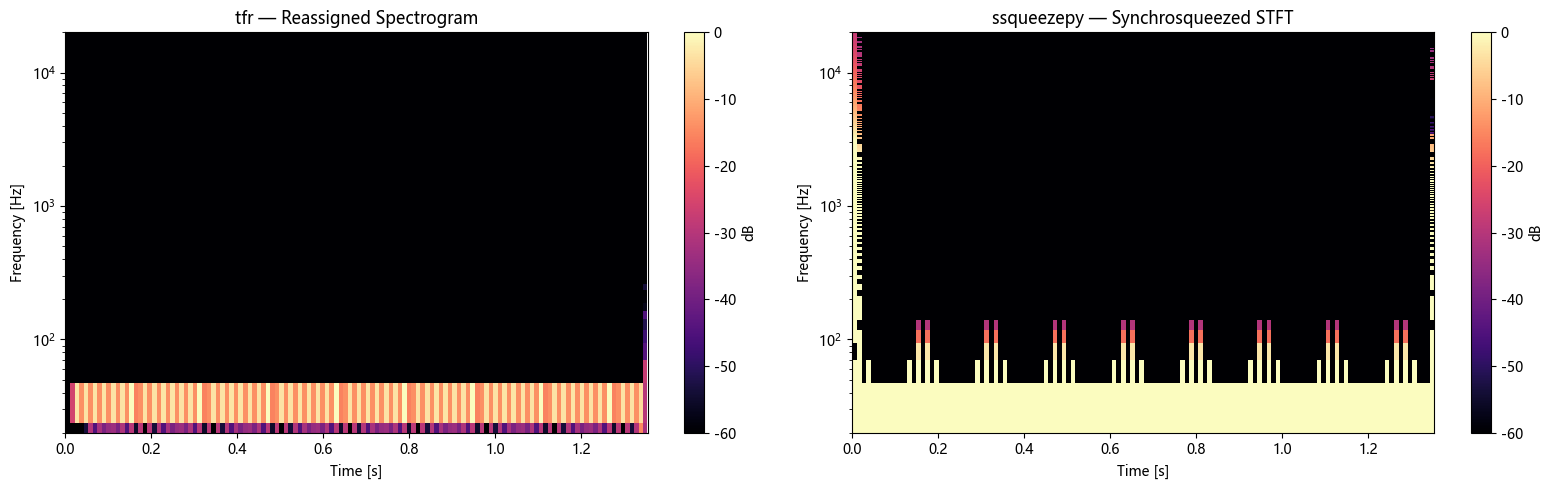

In [195]:
# ------------------------------------------------------------
# 已有轮子对比: tfr + ssqueezepy
# ------------------------------------------------------------
# tfr:          核密度式重分配 (cross-spectral), Hann 窗, 默认参数
# ssqueezepy:   Synchrosqueezed STFT, 挤压能量到瞬时频率位置
# ============================================================

import scipy
# tfr 依赖 scipy.hanning (已废弃), 做个兼容
scipy.hanning = scipy.signal.windows.hann

import tfr
from ssqueezepy import ssq_stft

n_fft = 2048
hop = 512

# ── 1. tfr: 重分配频谱图 ──
signal_frames = tfr.SignalFrames(y, frame_size=n_fft, hop_size=hop, sample_rate=sr)
spec_tfr = tfr.reassigned_spectrogram(
    signal_frames,
    reassign_time=True,
    reassign_frequency=True,
)

# tfr 输出: (time_frames, freq_bins), dB 值, 线性频率轴
n_tfr_time = spec_tfr.shape[0]
n_tfr_freq = spec_tfr.shape[1]
tfr_time = np.arange(n_tfr_time) * hop / sr
tfr_freq = np.linspace(0, sr / 2, n_tfr_freq)  # 线性, 不含 Nyquist

# ── 2. ssqueezepy: 同步挤压 STFT ──
Tx, Sx, ssq_freqs, _ = ssq_stft(
    y, n_fft=n_fft, hop_len=hop, fs=sr,
    window='hann', dtype='float64',
)
# Tx: (n_freq, n_frames), 复数
Tx_db = 20 * np.log10(np.abs(Tx) + 1e-12)
n_ssq_time = Tx.shape[1]
ssq_time = np.arange(n_ssq_time) * hop / sr

# ── 3. 并排绘制 ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# tfr
extent_tfr = [tfr_time[0], tfr_time[-1], tfr_freq[0], tfr_freq[-1]]
im1 = ax1.imshow(
    spec_tfr.T, aspect="auto", origin="lower", cmap="magma",
    extent=extent_tfr, vmin=-60, vmax=0,
)
ax1.set_yscale("log")
ax1.set_ylim(20, 20000)
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Frequency [Hz]")
ax1.set_title("tfr — Reassigned Spectrogram")
fig.colorbar(im1, ax=ax1, label="dB")

# ssqueezepy
extent_ssq = [ssq_time[0], ssq_time[-1], ssq_freqs[0], ssq_freqs[-1]]
im2 = ax2.imshow(
    Tx_db, aspect="auto", origin="lower", cmap="magma",
    extent=extent_ssq, vmin=-60, vmax=0,
)
ax2.set_yscale("log")
ax2.set_ylim(20, 20000)
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Frequency [Hz]")
ax2.set_title("ssqueezepy — Synchrosqueezed STFT")
fig.colorbar(im2, ax=ax2, label="dB")

fig.tight_layout()
plt.show()

已有的论子不是原生log，它们在log下低频都是块状的，失败失败  
# 试试LORIS的后处理


收敛指示器 (Convergence Indicator)

来自 Loris 的 mixed partial derivative ∂²ϕ/(∂t∂ω)  
值域 [0, 1]: 0 = 纯正弦, 1 = 纯脉冲  
用来判断每个 TF bin 的重分配结果是否可信

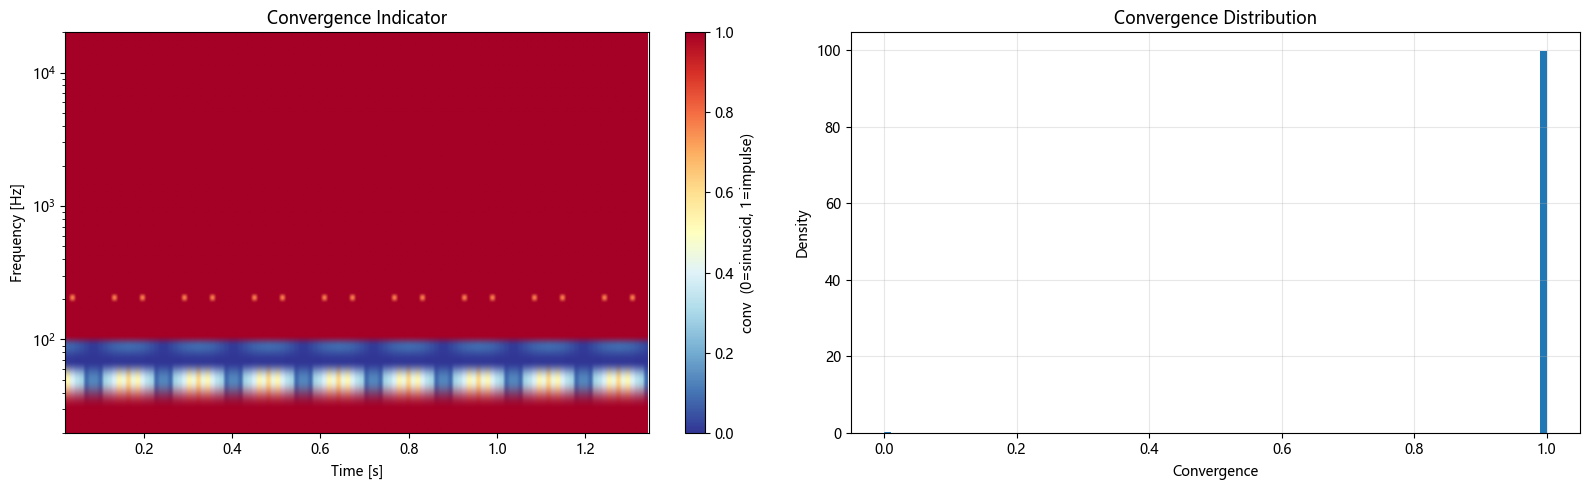

In [196]:
# ------------------------------------------------------------
# 收敛指示器 (Convergence Indicator)
# ------------------------------------------------------------
# 需要 4 个 DFT 量:
#   X_h   = FFT(x · w)        标准窗
#   X_dh  = FFT(x · dw)       导数窗
#   X_th  = FFT(x · tw)       时间加权窗, tw = (n-N/2)·w
#   X_tdh = FFT(x · tdw)      时间加权导数窗, tdw = (n-N/2)·dw
#
# 收敛值 ∈ [0, 1]:
#   term1 = Re(X_tdh · conj(X_h)) / |X_h|²
#   term2 = Re((X_th · X_dh) / X_h²)
#   conv  = |1 + (2π/N) · (term1 - term2)|  clipped to [0,1]
# ============================================================


def compute_convergence(
    y,
    sr,
    n_fft=2048,
    hop=512,
    zero_pad=1,
    f_lim=(20, 20000),
):
    fft_len = n_fft * zero_pad
    n_freq_out = fft_len // 2 + 1

    # 窗 + 导数窗 (匹配 Loris 缩放)
    w, dw_analytic = _blackman_window(n_fft)  # dw_analytic = N · dw/dn
    winsum = np.sum(w)

    # Loris: mWindow = w · 2/winsum  (用于 X_h)
    w_scaled = w * 2.0 / winsum

    # Loris: framp = dw/dn · N/(winsum·π)  (用于 X_dh)
    # dw_analytic = N·dw/dn, 所以:
    # dw_scaled = dw_analytic / (winsum · π)
    dw_scaled = dw_analytic / (winsum * np.pi)

    # Loris 时间斜坡: t = n - (N-1)/2
    n_arr = np.arange(n_fft)
    offset = (n_fft - 1) / 2.0
    tw = w_scaled * (n_arr - offset)
    tdw = dw_scaled * (n_arr - offset)

    n_frames = (len(y) - n_fft) // hop + 1

    f_min, f_max = f_lim
    log_f_min = np.log10(f_min)
    log_f_max = np.log10(f_max)

    log_freq_axis = np.linspace(log_f_min, log_f_max, n_freq_out)
    freq_axis = 10**log_freq_axis

    grid_conv = np.zeros((n_frames, n_freq_out))
    time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr

    bin_hz = sr / fft_len
    scale_by = 2 * np.pi / n_fft

    for m in range(n_frames):
        seg = y[m * hop : m * hop + n_fft]

        # 4 个 FFT (使用 Loris 缩放的窗)
        X_h = np.fft.rfft(seg * w_scaled, n=fft_len)
        X_dh = np.fft.rfft(seg * dw_scaled, n=fft_len)
        X_th = np.fft.rfft(seg * tw, n=fft_len)
        X_tdh = np.fft.rfft(seg * tdw, n=fft_len)

        mag_sq = np.maximum(np.abs(X_h) ** 2, 1e-20)

        # Loris 收敛指示器
        term1 = np.real(X_tdh * np.conj(X_h)) / mag_sq
        term2 = np.real((X_th * X_dh) / (X_h * X_h + 1e-20))
        conv = np.abs(1.0 + scale_by * (term1 - term2))
        conv = np.clip(conv, 0.0, 1.0)

        grid_conv[m, :] = conv

    return grid_conv, time_axis, freq_axis


# ── 计算并绘制 ──
grid_conv, time_axis, freq_axis = compute_convergence(
    y, sr, n_fft=2048, hop=512, zero_pad=1, f_lim=(20, 20000),
)

extent = [time_axis[0], time_axis[-1], freq_axis[0], freq_axis[-1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 收敛图
im1 = ax1.imshow(
    grid_conv.T, aspect="auto", origin="lower", cmap="RdYlBu_r",
    extent=extent, vmin=0, vmax=1,
)
ax1.set_yscale("log")
ax1.set_ylim(20, 20000)
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Frequency [Hz]")
ax1.set_title("Convergence Indicator")
fig.colorbar(im1, ax=ax1, label="conv  (0=sinusoid, 1=impulse)")

# 收敛值的直方图分布
ax2.hist(grid_conv.ravel(), bins=100, range=(0, 1), density=True)
ax2.set_xlabel("Convergence")
ax2.set_ylabel("Density")
ax2.set_title("Convergence Distribution")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

将收敛指示器应用到重分配中

用 (1 - conv) 加权每个 bin 的能量，高收敛（不可信）的 bin 贡献趋近 0

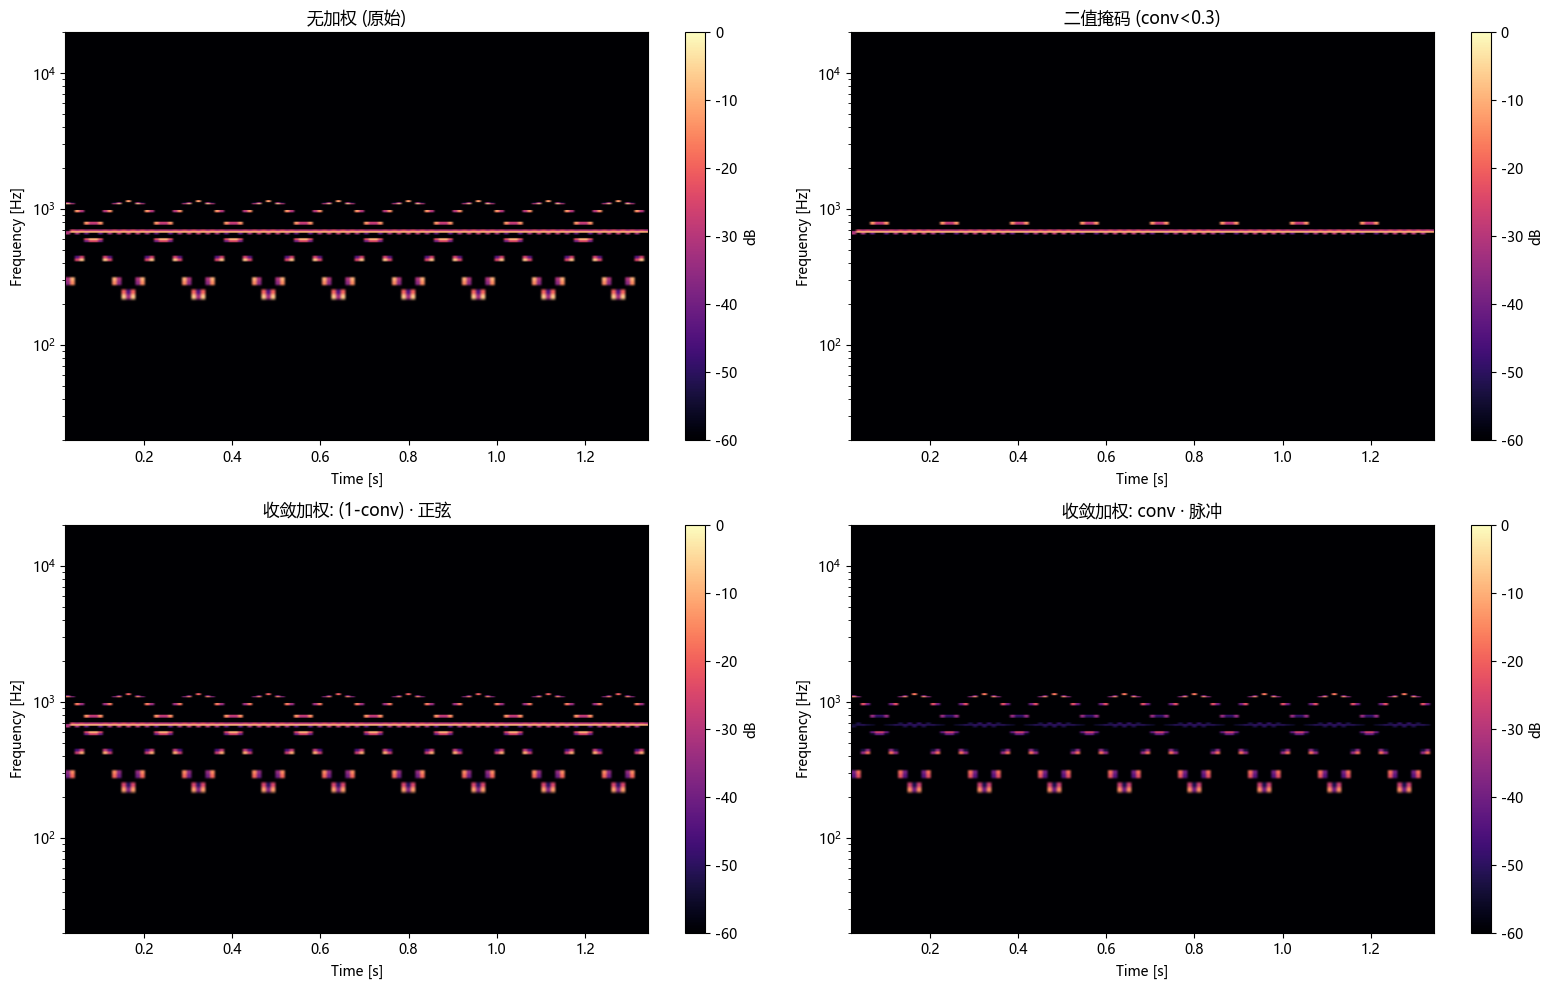

In [197]:
# ------------------------------------------------------------
# 收敛加权重分配 (Convergence-Weighted Reassignment)
# ------------------------------------------------------------
# 重分配使用 cell 6 原始缩放 (匹配 C++)
# 收敛使用 Loris 缩放 (全套 4 个 FFT)
# 对比: 无加权 vs 二值掩码 vs 收敛加权(正弦) vs 收敛加权(脉冲)
# ============================================================


def reassigned_spectrogram_conv_weighted(
    y,
    sr,
    n_fft=2048,
    hop=512,
    zero_pad=1,
    conv_threshold=0.5,
    f_lim=(20, 20000),
):
    fft_len = n_fft * zero_pad
    n_freq_out = fft_len // 2 + 1

    # ── 窗: cell 6 缩放 (重分配用) ──
    w, dw_analytic = _blackman_window(n_fft)
    w_gain = 1.0 / np.mean(w)
    w_c6 = w * w_gain
    dw_c6 = dw_analytic * w_gain
    tw_c6 = w_c6 * (np.arange(n_fft) - n_fft / 2.0)

    # ── 窗: Loris 缩放 (收敛用) ──
    winsum = np.sum(w)
    w_l = w * 2.0 / winsum
    dw_l = dw_analytic / (winsum * np.pi)
    off_l = (n_fft - 1) / 2.0
    tw_l = w_l * (np.arange(n_fft) - off_l)
    tdw_l = dw_l * (np.arange(n_fft) - off_l)

    n_frames = (len(y) - n_fft) // hop + 1
    frame_dur = n_fft / sr
    dt = hop / sr
    scale_by = 2 * np.pi / n_fft
    bin_hz = sr / fft_len

    f_min, f_max = f_lim
    log_f_min = np.log10(f_min)
    log_f_max = np.log10(f_max)

    grid_raw = np.zeros((n_frames, n_freq_out))
    grid_masked = np.zeros((n_frames, n_freq_out))
    grid_sine = np.zeros((n_frames, n_freq_out))
    grid_impulse = np.zeros((n_frames, n_freq_out))

    time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr

    for m in range(n_frames):
        seg = y[m * hop : m * hop + n_fft]

        # 重分配 FFT (cell 6 缩放)
        X_h = np.fft.rfft(seg * w_c6, n=fft_len)
        X_dh = np.fft.rfft(seg * dw_c6, n=fft_len)
        X_th = np.fft.rfft(seg * tw_c6, n=fft_len)

        # 收敛 FFT (Loris 缩放, 全套)
        Xh_l = np.fft.rfft(seg * w_l, n=fft_len)
        Xdh_l = np.fft.rfft(seg * dw_l, n=fft_len)
        Xth_l = np.fft.rfft(seg * tw_l, n=fft_len)
        Xtdh_l = np.fft.rfft(seg * tdw_l, n=fft_len)

        mag_sq = np.maximum(np.abs(X_h) ** 2, 1e-20)
        mag_lin = np.abs(X_h) / n_fft
        t_center = time_axis[m]

        # 频率重分配 (导数窗, cell 6)
        freq_corr = -np.imag(np.conj(X_h) * X_dh) * zero_pad / (2 * np.pi * mag_sq)
        inst_freq_hz = (np.arange(n_freq_out) + freq_corr) * bin_hz

        # 时间重分配
        time_offset = np.real(np.conj(X_h) * X_th) / mag_sq
        group_delay = time_offset / n_fft

        # 收敛指示器 (Loris 缩放, 全套)
        msq_l = np.maximum(np.abs(Xh_l) ** 2, 1e-20)
        term1 = np.real(Xtdh_l * np.conj(Xh_l)) / msq_l
        term2 = np.real((Xth_l * Xdh_l) / (Xh_l * Xh_l + 1e-20))
        conv = np.abs(1.0 + scale_by * (term1 - term2))
        conv = np.clip(conv, 0.0, 1.0)

        for k in range(n_freq_out):
            f_reassigned = inst_freq_hz[k]
            if f_reassigned < f_min or f_reassigned > f_max:
                continue

            log_f = np.log10(f_reassigned)
            f_pos = (log_f - log_f_min) / (log_f_max - log_f_min) * (n_freq_out - 1)
            f_idx = int(np.floor(f_pos))
            f_frac = f_pos - f_idx
            if f_idx < 0 or f_idx >= n_freq_out - 1:
                continue

            t_reassigned = t_center + group_delay[k] * frame_dur
            t_pos = (t_reassigned - time_axis[0]) / dt
            t_idx = int(np.floor(t_pos))
            t_frac = t_pos - t_idx
            if t_idx < 0 or t_idx >= n_frames - 1:
                continue

            wgt_raw = mag_lin[k]
            wgt_masked = wgt_raw if conv[k] < conv_threshold else 0.0
            wgt_sine = wgt_raw * (1.0 - conv[k])
            wgt_impulse = wgt_raw * conv[k]

            def _distribute(grid, w):
                grid[t_idx, f_idx] += w * (1 - t_frac) * (1 - f_frac)
                grid[t_idx, f_idx + 1] += w * (1 - t_frac) * f_frac
                grid[t_idx + 1, f_idx] += w * t_frac * (1 - f_frac)
                grid[t_idx + 1, f_idx + 1] += w * t_frac * f_frac

            _distribute(grid_raw, wgt_raw)
            _distribute(grid_masked, wgt_masked)
            _distribute(grid_sine, wgt_sine)
            _distribute(grid_impulse, wgt_impulse)

    return grid_raw, grid_masked, grid_sine, grid_impulse, time_axis


grid_raw, grid_masked, grid_sine, grid_impulse, time_axis = (
    reassigned_spectrogram_conv_weighted(
        y,
        sr,
        n_fft=2048,
        hop=512,
        zero_pad=1,
        conv_threshold=0.1
    )
)

# log 频率轴
freq_axis_out = np.logspace(np.log10(20), np.log10(20000), grid_raw.shape[1])
extent = [time_axis[0], time_axis[-1], freq_axis_out[0], freq_axis_out[-1]]

_db_lo, _db_hi = -60, 0

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
titles = [
    "无加权 (原始)",
    f"二值掩码 (conv<0.3)",
    "收敛加权: (1-conv) · 正弦",
    "收敛加权: conv · 脉冲",
]
grids = [grid_raw, grid_masked, grid_sine, grid_impulse]

for ax, g, title in zip(axes.flat, grids, titles):
    g_db = 20 * np.log10(g.T + 1e-12)
    im = ax.imshow(
        g_db,
        aspect="auto",
        origin="lower",
        cmap="magma",
        extent=extent,
        vmin=_db_lo,
        vmax=_db_hi,
    )
    ax.set_yscale("log")
    ax.set_ylim(20, 20000)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="dB")

fig.tight_layout()
plt.show()

# 收敛指示器 (Convergence Indicator) 计算流程

源自 Loris 库 (Kelly Fitz & Lippold Haken)，基于 Auger-Flandrin 重分配方法。

---

## 1. 目的

衡量每个 TF bin 的**混合偏导数** $\partial^2\phi/(\partial t\,\partial\omega)$，判断该 bin 更像正弦波还是脉冲：

- **conv → 0**：纯正弦（相位线性变化），重分配结果可信
- **conv → 1**：纯脉冲（相位随机），重分配结果不可信

---

## 2. 需要的 4 个 DFT 量

### 起点：`_blackman_window(n_fft)` 返回

```python
w, dw_analytic = _blackman_window(n_fft)
# w            = 标准 Blackman 窗 (周期式)
# dw_analytic  = N · dw/dn  (窗对采样点索引 n 的导数 × N)
```

### Loris 缩放（收敛用）

对 `w` 和 `dw_analytic` 做两件事：**缩放幅度** + **加时间斜坡**。

| 量 | 幅度缩放 | 加时间斜坡 | 最终窗 |
|----|---------|-----------|--------|
| $X_h$ 用 | `w_l = w · 2 / sum(w)` | 不加 | `w_l` |
| $X_{dh}$ 用 | `dw_l = dw_analytic / (sum·π)` | 不加 | `dw_l` |
| $X_{th}$ 用 | 同 $w_l$ | `tw_l = w_l · (n - (N-1)/2)` | `tw_l` |
| $X_{tdh}$ 用 | 同 $dw_l$ | `tdw_l = dw_l · (n - (N-1)/2)` | `tdw_l` |

```python
winsum = np.sum(w)
w_l   = w * 2.0 / winsum            # X_h  用, 窗总和 = 2
dw_l  = dw_analytic / (winsum * np.pi)  # X_dh 用

off   = (n_fft - 1) / 2.0
tw_l  = w_l  * (np.arange(n_fft) - off)   # X_th  用
tdw_l = dw_l * (np.arange(n_fft) - off)   # X_tdh 用
```

> **为什么 `dw_l` 多一个 `π`？** 因为 Loris 把导数窗打包进复数窗的实部时，额外除了 $\pi$ 来匹配其 FFT 缩放约定。这是 Loris 特有的，直接照用即可。

### C++/cell6 缩放对比（重分配用）

用于频率/时间校正，**不能**用于收敛：

```python
w_c6  = w * w_gain          # w_gain = N / sum(w), 窗总和 = N
dw_c6 = dw_analytic * w_gain
tw_c6 = w_c6 * (n - N/2)
```

---

## 3. 收敛公式

$$
\begin{aligned}
t_1 &= \frac{\Re\big( X_{tdh} \cdot X_h^* \big)}{|X_h|^2} \\[6pt]
t_2 &= \Re\left( \frac{X_{th} \cdot X_{dh}}{X_h^2} \right) \\[6pt]
s &= \frac{2\pi}{N} \\[6pt]
c &= \bigl|\, 1 + s \cdot (t_1 - t_2)\, \bigr| \\[4pt]
c &= \min(\max(c, 0), 1)
\end{aligned}
$$

### 逐项意义

- **$t_1$**：来自 `mMagnitudeTransform` 的 odd part（$X_{tdh}$）与 even part（$X_h$）的比值实部 — 反映时间×频率混合矩
- **$t_2$**：来自两个变换的交叉项 — 反映时间矩与频率矩的乘积
- **$s$**：$2\pi/N$ 将离散 DFT 域的尺度映射到连续相位导数

当 $c \to 0$ 时，有：

$$1 + \frac{2\pi}{N}(t_1 - t_2) \approx 0 \quad\Longrightarrow\quad t_1 - t_2 \approx -\frac{N}{2\pi}$$

这对应 $\partial^2\phi/(\partial t\,\partial\omega)=0$（纯正弦的相位是时间线性函数）。

---

## 4. Python 实现步骤

```python
# 1. 构建 Loris 缩放的窗
w, dw_analytic = _blackman_window(n_fft)    # dw_analytic = N · dw/dn
winsum = np.sum(w)

w_l = w * 2.0 / winsum                      # X_h 用
dw_l = dw_analytic / (winsum * np.pi)        # X_dh 用

off = (n_fft - 1) / 2.0
tw_l = w_l * (np.arange(n_fft) - off)        # X_th 用
tdw_l = dw_l * (np.arange(n_fft) - off)      # X_tdh 用

# 2. 每帧计算 4 个 FFT
Xh_l  = np.fft.rfft(seg * w_l,   n=fft_len)
Xdh_l = np.fft.rfft(seg * dw_l,  n=fft_len)
Xth_l = np.fft.rfft(seg * tw_l,  n=fft_len)
Xtdh_l= np.fft.rfft(seg * tdw_l, n=fft_len)

# 3. 收敛值
msq   = np.maximum(np.abs(Xh_l)**2, 1e-20)
term1 = np.real(Xtdh_l * np.conj(Xh_l)) / msq
term2 = np.real((Xth_l * Xdh_l) / (Xh_l * Xh_l + 1e-20))
scale_by = 2 * np.pi / n_fft
conv  = np.abs(1.0 + scale_by * (term1 - term2))
conv  = np.clip(conv, 0.0, 1.0)
```

---

## 5. 在重分配中的应用

conv 作为**权重**作用于每个 bin 的幅度，在双线性分布前加权：

| 方式 | 权重 | 效果 |
|------|------|------|
| 无加权 | $w = \text{mag}$ | 原始重分配 |
| 二值掩码 | $w = \text{mag} \cdot [\text{conv} < \text{threshold}]$ | 只保留最可信的正弦 bin |
| 正弦加权 | $w = \text{mag} \cdot (1 - \text{conv})$ | 压制脉冲/噪声，保留正弦 |
| 脉冲加权 | $w = \text{mag} \cdot \text{conv}$ | 压制正弦，只显示脉冲/噪声 |

> **注意**：重分配本身的频率/时间校正（`freq_corr`, `group_delay`）需使用 **C++ cell 6 缩放**的窗。收敛计算使用独立的 **Loris 缩放**窗。每帧共需 7 次 FFT（3 次 C++ 缩放 + 4 次 Loris 缩放）。


峰值筛选 — 使用重分配最小值法剔除旁瓣

基于 Loris SpectralPeakSelector::selectReassignmentMinima  
原理: 当能量汇聚时, 相邻 bin 的重分配频率方向反转
  f_rs[j]   > j   (正校正)  
  f_rs[j+1] < j+1 (负校正)  
  → 峰值位于 bin j 和 j+1 之间

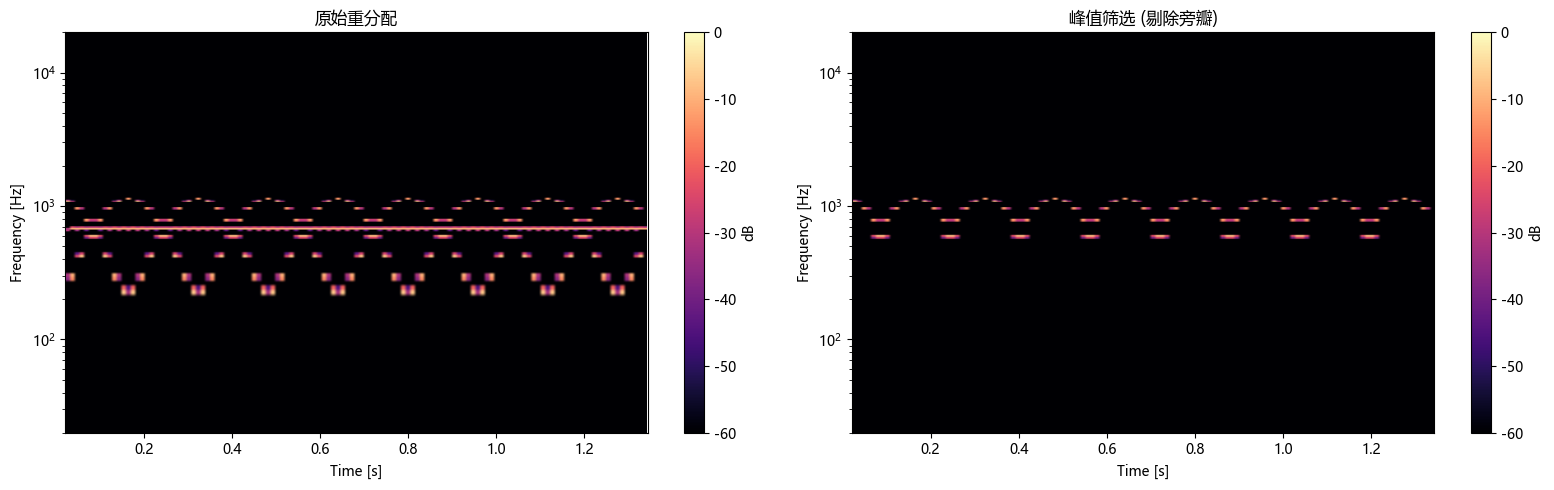

In [198]:
# ------------------------------------------------------------
# 峰值筛选 — 重分配最小值法剔除旁瓣
# ------------------------------------------------------------
# 在导数窗重分配基础上, 对每帧做峰值检测:
#   找 f_rs[j] > j 且 f_rs[j+1] < j+1 的位置 → 峰值
#   只保留峰值 bin 的能量参与分布
# ============================================================


def _blackman_window(n_fft):
    a0, a1, a2 = 0.42, 0.5, 0.08
    n = np.arange(n_fft)
    t = n / n_fft
    twopi = 2 * np.pi
    w = a0 - a1 * np.cos(twopi * t) + a2 * np.cos(2 * twopi * t)
    dw = a1 * twopi * np.sin(twopi * t) - a2 * (2 * twopi) * np.sin(2 * twopi * t)
    return w, dw


def find_peaks_reassignment(freq_corr):
    """Loris 式重分配最小值峰值检测.
    
    找 f_rs[j] > j 且 f_rs[j+1] < j+1 的方向反转点.
    f_rs[k] = k + freq_corr[k] (小数 bin 位置)
    """
    n = len(freq_corr)
    peak_mask = np.zeros(n, dtype=bool)
    f_rs = np.arange(n) + freq_corr
    
    for j in range(1, n - 2):
        if f_rs[j] > j and f_rs[j + 1] < j + 1:
            if (f_rs[j] - j) < (j + 1 - f_rs[j + 1]):
                peak_mask[j] = True
            else:
                peak_mask[j + 1] = True
    
    return peak_mask


def reassigned_spectrogram_peaks(
    y, sr, n_fft=2048, hop=512, zero_pad=1, f_lim=(20, 20000),
):
    fft_len = n_fft * zero_pad
    n_freq_out = fft_len // 2 + 1

    w, dw = _blackman_window(n_fft)
    w_gain = 1.0 / np.mean(w)
    w *= w_gain
    dw *= w_gain
    
    tw = w * (np.arange(n_fft) - n_fft / 2.0)

    n_frames = (len(y) - n_fft) // hop + 1
    frame_dur = n_fft / sr
    dt = hop / sr
    bin_hz = sr / fft_len

    f_min, f_max = f_lim
    log_f_min = np.log10(f_min)
    log_f_max = np.log10(f_max)

    grid_raw = np.zeros((n_frames, n_freq_out))
    grid_peaks = np.zeros((n_frames, n_freq_out))
    time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr

    for m in range(n_frames):
        seg = y[m * hop : m * hop + n_fft]

        X_h = np.fft.rfft(seg * w, n=fft_len)
        X_dh = np.fft.rfft(seg * dw, n=fft_len)
        X_th = np.fft.rfft(seg * tw, n=fft_len)

        mag_sq = np.maximum(np.abs(X_h) ** 2, 1e-20)
        mag_lin = np.abs(X_h) / n_fft
        t_center = time_axis[m]

        freq_corr = -np.imag(np.conj(X_h) * X_dh) * zero_pad / (2 * np.pi * mag_sq)
        inst_freq_hz = (np.arange(n_freq_out) + freq_corr) * bin_hz

        time_offset = np.real(np.conj(X_h) * X_th) / mag_sq
        group_delay = time_offset / n_fft

        # ── 峰值检测 (仅频率校正方向反转) ──
        peak_mask = find_peaks_reassignment(freq_corr)

        for k in range(n_freq_out):
            f = inst_freq_hz[k]
            if f < f_min or f > f_max:
                continue

            log_f = np.log10(f)
            f_pos = (log_f - log_f_min) / (log_f_max - log_f_min) * (n_freq_out - 1)
            f_idx = int(np.floor(f_pos))
            f_frac = f_pos - f_idx
            if f_idx < 0 or f_idx >= n_freq_out - 1:
                continue

            t_r = t_center + group_delay[k] * frame_dur
            t_pos = (t_r - time_axis[0]) / dt
            t_idx = int(np.floor(t_pos))
            t_frac = t_pos - t_idx
            if t_idx < 0 or t_idx >= n_frames - 1:
                continue

            wgt = mag_lin[k]

            def _dist(grid, w):
                grid[t_idx, f_idx] += w * (1 - t_frac) * (1 - f_frac)
                grid[t_idx, f_idx + 1] += w * (1 - t_frac) * f_frac
                grid[t_idx + 1, f_idx] += w * t_frac * (1 - f_frac)
                grid[t_idx + 1, f_idx + 1] += w * t_frac * f_frac

            _dist(grid_raw, wgt)
            if peak_mask[k]:
                _dist(grid_peaks, wgt)

    return grid_raw, grid_peaks, time_axis


grid_raw, grid_peaks, time_axis = reassigned_spectrogram_peaks(
    y, sr, n_fft=2048, hop=512, zero_pad=1,
)

freq_axis_out = np.logspace(np.log10(20), np.log10(20000), grid_raw.shape[1])
extent = [time_axis[0], time_axis[-1], freq_axis_out[0], freq_axis_out[-1]]

_db_lo, _db_hi = -60, 0
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
titles = ["原始重分配", "峰值筛选 (剔除旁瓣)"]
grids = [grid_raw, grid_peaks]

for ax, g, title in zip(axes, grids, titles):
    g_db = 20 * np.log10(g.T + 1e-12)
    im = ax.imshow(g_db, aspect="auto", origin="lower", cmap="magma",
                   extent=extent, vmin=_db_lo, vmax=_db_hi)
    ax.set_yscale("log")
    ax.set_ylim(20, 20000)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="dB")

fig.tight_layout()
plt.show()

删除旁瓣 — 方向反转点实为旁瓣位置

实验发现方向反转点出现在旁瓣而非主瓣。  
反转逻辑: 删除方向反转点处的能量以抑制旁瓣。

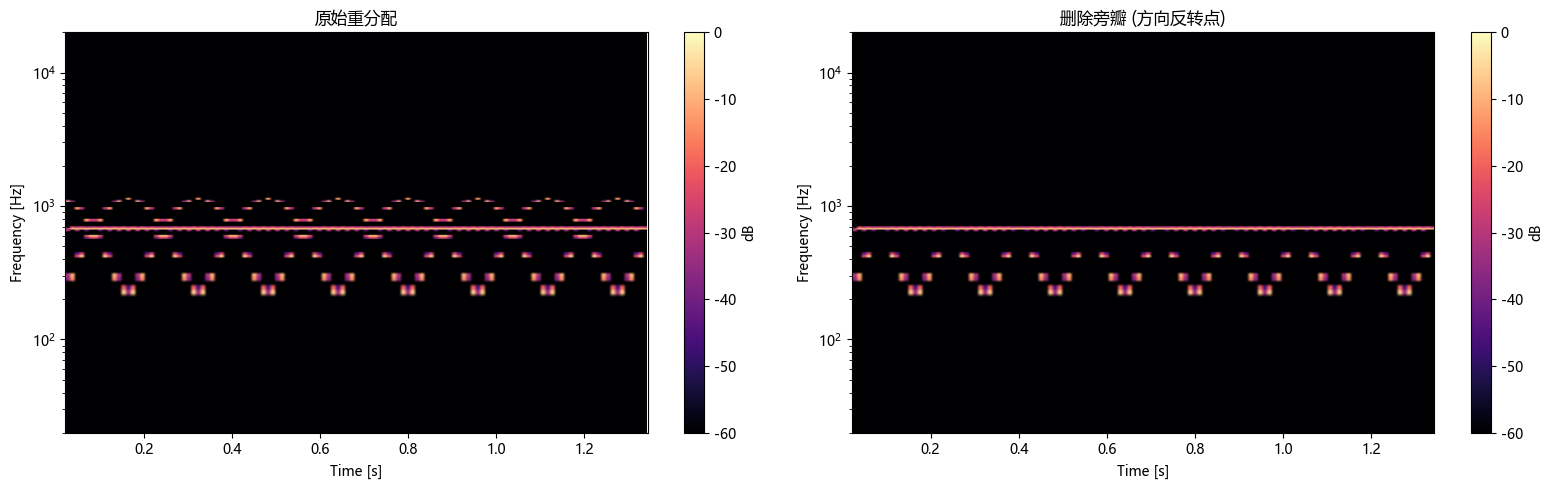

In [199]:
# ------------------------------------------------------------
# 删除峰值 — 方向反转点实为旁瓣
# ------------------------------------------------------------
# 实验发现方向反转点出现在旁瓣位置而非主瓣,
# 因此反转逻辑: 删除这些 bin 的能量以抑制旁瓣
# ============================================================


def reassigned_spectrogram_notch_peaks(
    y, sr, n_fft=2048, hop=512, zero_pad=1, f_lim=(20, 20000),
):
    fft_len = n_fft * zero_pad
    n_freq_out = fft_len // 2 + 1

    w, dw = _blackman_window(n_fft)
    w_gain = 1.0 / np.mean(w)
    w *= w_gain
    dw *= w_gain
    tw = w * (np.arange(n_fft) - n_fft / 2.0)

    n_frames = (len(y) - n_fft) // hop + 1
    frame_dur = n_fft / sr
    dt = hop / sr
    bin_hz = sr / fft_len
    f_min, f_max = f_lim
    log_f_min = np.log10(f_min)
    log_f_max = np.log10(f_max)

    grid_raw = np.zeros((n_frames, n_freq_out))
    grid_notched = np.zeros((n_frames, n_freq_out))
    time_axis = (np.arange(n_frames) * hop + (n_fft - 1) / 2) / sr

    for m in range(n_frames):
        seg = y[m * hop : m * hop + n_fft]

        X_h = np.fft.rfft(seg * w, n=fft_len)
        X_dh = np.fft.rfft(seg * dw, n=fft_len)
        X_th = np.fft.rfft(seg * tw, n=fft_len)

        mag_sq = np.maximum(np.abs(X_h) ** 2, 1e-20)
        mag_lin = np.abs(X_h) / n_fft
        t_center = time_axis[m]

        freq_corr = -np.imag(np.conj(X_h) * X_dh) * zero_pad / (2 * np.pi * mag_sq)
        inst_freq_hz = (np.arange(n_freq_out) + freq_corr) * bin_hz

        time_offset = np.real(np.conj(X_h) * X_th) / mag_sq
        group_delay = time_offset / n_fft

        # 检测方向反转点 (实测为旁瓣位置)
        f_rs = np.arange(n_freq_out) + freq_corr
        sidelobe_mask = np.zeros(n_freq_out, dtype=bool)
        for j in range(1, n_freq_out - 2):
            if f_rs[j] > j and f_rs[j + 1] < j + 1:
                if (f_rs[j] - j) < (j + 1 - f_rs[j + 1]):
                    sidelobe_mask[j] = True
                else:
                    sidelobe_mask[j + 1] = True

        for k in range(n_freq_out):
            f = inst_freq_hz[k]
            if f < f_min or f > f_max:
                continue

            log_f = np.log10(f)
            f_pos = (log_f - log_f_min) / (log_f_max - log_f_min) * (n_freq_out - 1)
            f_idx = int(np.floor(f_pos))
            f_frac = f_pos - f_idx
            if f_idx < 0 or f_idx >= n_freq_out - 1:
                continue

            t_r = t_center + group_delay[k] * frame_dur
            t_pos = (t_r - time_axis[0]) / dt
            t_idx = int(np.floor(t_pos))
            t_frac = t_pos - t_idx
            if t_idx < 0 or t_idx >= n_frames - 1:
                continue

            wgt = mag_lin[k]

            def _dist(grid, w):
                grid[t_idx, f_idx] += w * (1 - t_frac) * (1 - f_frac)
                grid[t_idx, f_idx + 1] += w * (1 - t_frac) * f_frac
                grid[t_idx + 1, f_idx] += w * t_frac * (1 - f_frac)
                grid[t_idx + 1, f_idx + 1] += w * t_frac * f_frac

            _dist(grid_raw, wgt)
            if not sidelobe_mask[k]:  # ← 反转: 删除旁瓣, 保留主瓣
                _dist(grid_notched, wgt)

    return grid_raw, grid_notched, time_axis


grid_raw, grid_notched, time_axis = reassigned_spectrogram_notch_peaks(
    y, sr, n_fft=2048, hop=512, zero_pad=1,
)

freq_axis_out = np.logspace(np.log10(20), np.log10(20000), grid_raw.shape[1])
extent = [time_axis[0], time_axis[-1], freq_axis_out[0], freq_axis_out[-1]]

_db_lo, _db_hi = -60, 0
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
titles = ["原始重分配", "删除旁瓣 (方向反转点)"]

for ax, g, title in zip(axes, [grid_raw, grid_notched], titles):
    g_db = 20 * np.log10(g.T + 1e-12)
    im = ax.imshow(g_db, aspect="auto", origin="lower", cmap="magma",
                   extent=extent, vmin=_db_lo, vmax=_db_hi)
    ax.set_yscale("log")
    ax.set_ylim(20, 20000)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="dB")

fig.tight_layout()
plt.show()